In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from PIL import Image
import numpy as np
import os
from sklearn.neighbors import KNeighborsClassifier


using the dataset in generating the data matrix and label vector then split the dataset into training abd test sets (1,2,3)

In [ ]:
parent_folder = '/content/drive/MyDrive/PR/assignment1'

width = 92
height = 112
#data array
D = np.zeros((400, 10304))
#centered trainig data array
DTraincentered = np.zeros((200, 10304))
#centered test data array
DTestcentered = np.zeros((200, 10304))
#keep track of the number of test and train images processed
testc=0
trainc=0
#training image data array
Dtrain = np.zeros((200, 10304))
#testing image data array
Dtest = np.zeros((200, 10304))
#labels array
Y = np.zeros(400)
#training image labels array
Ytrain = np.zeros((200, 1))
#testing image labels array
Ytest = np.zeros((200, 1))

#loop iterates over the parent folder, where we hae 40 subdirectories each representing a different subject
for sub in range(1,41):
  #sets the path to the subdirectory for the current subject
  folder_path = f"{parent_folder}/s{sub}"
  #loop iterates over the images in each subject's subdirectory, we have 10 images per subject
  for i in range(1,11):
    #sets the path of current image
    filename = f"{folder_path}/{i}.pgm" 
    image = Image.open(filename) 
    #convert image to numpy array
    image_array = np.array(image)
    #flatten the image and store it in data array
    D[(sub-1)*10+(i-1)] = image_array.flatten() 
    #store the label of the image in labels' array
    Y[(sub-1)*10+(i-1)] = sub
    #if odd -> assign the data as test data
    #if even -> assign the data as train data
    if (i % 2) != 0:
      Dtest[testc] = D[(sub-1)*10+(i-1)]
      Ytest[int(testc)] = Y[(sub-1)*10+(i-1)]
      testc=testc+1
    else:
      Dtrain[trainc] = D[(sub-1)*10+(i-1)]
      Ytrain[int(trainc)] = Y[(sub-1)*10+(i-1)]
      trainc=trainc+1

#subtract the mean of the column from every element in that column
#used for train data
for i in range(0,10304):
  DTraincentered[:,i]=Dtrain[:,i]-Dtrain[:,i].mean()
#similar as the previous loop, but this loop is for test data
for i in range(0,10304):
  DTestcentered[:,i]=Dtest[:,i]-Dtrain[:,i].mean()

4. PCA Classification

In [ ]:
#4
# Compute the covariance matrix of the centered training data
covarianceMatrix = np.cov(DTraincentered.T)
# Compute the eigenvalues and eigenvectors of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eigh(covarianceMatrix)
# sort the absolute values of the eigenvalues in descending order 
#and return the indices that would sort the eigenvalues in this order.
idx = np.argsort(-np.absolute(eigenvalues))   
eigenValues = eigenvalues[idx]
eigenVectors = eigenvectors[:,idx]


In [ ]:
R=np.zeros(4)
#compute the number of principal components required to explain certain percentages of the total variance in a dataset.
#every loop loops through the eigenvalues and calculate the percentage of total variance
#then check if this percentage is greater than the target percentage
#then set the corresponding R to the computed percentage of total variance

for i in range(0,200):
  explained=eigenValues[0:i].sum()/eigenValues.sum()
  if explained > 0.8:
    R[0]=i
    break
for i in range(i,200):
  explained=eigenValues[0:i].sum()/eigenValues.sum()
  if explained > 0.85:
    R[1]=i
    break
for i in range(i,200):
  explained=eigenValues[0:i].sum()/eigenValues.sum()
  if explained > 0.9:
    R[2]=i
    break
for i in range(i,200):
  explained=eigenValues[0:i].sum()/eigenValues.sum()
  if explained > 0.95:
    R[3]=i
    break
print(R)

[ 37.  53.  77. 116.]


In [ ]:
#U1,U2,U3,U4 are 2D arrays each containing a subset of the columns of eigenvectors
#the arrays contain the eigenvectors of the covariance matrix of the training data
# sorted in descending order of their corresponding eigenvalues
#those arrays are used to construct the projection matrices
U1=eigenVectors[:,:int(R[0])]
U2=eigenVectors[:,:int(R[1])]
U3=eigenVectors[:,:int(R[2])]
U4=eigenVectors[:,:int(R[3])]

In [ ]:
#projection of centered training data onto that eigenvector
#taking the dot product of the centered training data with the corresponding eigenvector
#the transpose of the projection matrix is used to transform the training data into the new coordinate system
projection_matrix = U1
projected_data1 = np.dot(projection_matrix.T, DTraincentered.T)
projection_matrix = U2
projected_data2 = np.dot(projection_matrix.T, DTraincentered.T)
projection_matrix = U3
projected_data3 = np.dot(projection_matrix.T, DTraincentered.T)
projection_matrix = U4
projected_data4 = np.dot(projection_matrix.T, DTraincentered.T)


In [ ]:
#same as the previous cell, but this is for test data.
projection_matrix = U1
projected_data5 = np.dot(projection_matrix.T, DTestcentered.T)
projection_matrix = U2
projected_data6 = np.dot(projection_matrix.T, DTestcentered.T)
projection_matrix = U3
projected_data7 = np.dot(projection_matrix.T, DTestcentered.T)
projection_matrix = U4
projected_data8 = np.dot(projection_matrix.T, DTestcentered.T)

In [ ]:
#the 1st 4 projected data arrays contain the projection of the centered training data
#onto the first four principal components obtained from PCA.
#the 2nd 4 projected data arrays contain the projection of the centered test data 
#onto the first four principal components obtained from PCA

#convert the complex valued  projections of the training and test data into real-valued projections.

projected_data1_real = np.real(projected_data1.T)
projected_data2_real = np.real(projected_data2.T)
projected_data3_real = np.real(projected_data3.T)
projected_data4_real = np.real(projected_data4.T)
projected_data5_real = np.real(projected_data5.T)
projected_data6_real = np.real(projected_data6.T)
projected_data7_real = np.real(projected_data7.T)
projected_data8_real = np.real(projected_data8.T)

In [ ]:
#create an instance of the classifier with k=1 used as the classification model
#fit the training data to the model along with the corresponding class labels Ytrain
#calculate the accuracy of the trained model on the test data and the corresponding class labels Ytrain
#the accuracy is calculated as the number of correct predictions divided by the total no of predictions

#here the number of neighbors is 1
#the process is repeated four times for four different datasets using same no of neighbors

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(projected_data1_real, Ytrain)
print("Accuracy with R = ", R[0], ": ", knn.score(projected_data5_real, Ytest))

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(projected_data2_real, Ytrain)
print("Accuracy with R = ", R[1], ": ", knn.score(projected_data6_real, Ytest))

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(projected_data3_real, Ytrain)
print("Accuracy with R = ", R[2], ": ", knn.score(projected_data7_real, Ytest))

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(projected_data4_real, Ytrain)
print("Accuracy with R = ", R[3], ": ", knn.score(projected_data8_real, Ytest))

Accuracy with R =  37.0 :  0.93
Accuracy with R =  53.0 :  0.94
Accuracy with R =  77.0 :  0.945
Accuracy with R =  116.0 :  0.935


/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exam

In [ ]:
#k here is the number of neighbors
#the code loops over a different values of k then calculates the accuracy
#for each value of k for each of the 4 datasets
#this is more efficient than the previous block as it uses a loop to perform 
#the same classification process with different values of k

#6.classifier tuning
k_values = [1, 3, 5, 7]

accuracy_R0=np.zeros(4)
accuracy_R1=np.zeros(4)
accuracy_R2=np.zeros(4)
accuracy_R3=np.zeros(4)

for i in range(0,4):
  knn = KNeighborsClassifier(n_neighbors=k_values[i])
  k=np.zeros(4)
  knn.fit(projected_data1_real, Ytrain)
  accuracy_R0[i]=knn.score(projected_data5_real, Ytest)
  print("Accuracy with R = ", R[0], "and number of neighbors =",k_values[i],": ", accuracy_R0[i])

  knn = KNeighborsClassifier(n_neighbors=k_values[i])
  knn.fit(projected_data2_real, Ytrain)
  accuracy_R1[i]=knn.score(projected_data6_real, Ytest)
  print("Accuracy with R = ", R[1],"and number of neighbors =",k_values[i], ": ",  accuracy_R1[i] )

  knn = KNeighborsClassifier(n_neighbors=k_values[i])
  knn.fit(projected_data3_real, Ytrain)
  accuracy_R2[i]=knn.score(projected_data7_real, Ytest)
  print("Accuracy with R = ", R[2],"and number of neighbors =",k_values[i], ": ", accuracy_R2[i])

  knn = KNeighborsClassifier(n_neighbors=k_values[i])
  knn.fit(projected_data4_real, Ytrain)
  accuracy_R3[i]=knn.score(projected_data8_real, Ytest)
  print("Accuracy with R = ", R[3],"and number of neighbors =",k_values[i], ": ", accuracy_R3[i])

/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exam

Accuracy with R =  37.0 and number of neighbors = 1 :  0.93
Accuracy with R =  53.0 and number of neighbors = 1 :  0.94
Accuracy with R =  77.0 and number of neighbors = 1 :  0.945
Accuracy with R =  116.0 and number of neighbors = 1 :  0.935
Accuracy with R =  37.0 and number of neighbors = 3 :  0.855
Accuracy with R =  53.0 and number of neighbors = 3 :  0.855
Accuracy with R =  77.0 and number of neighbors = 3 :  0.85
Accuracy with R =  116.0 and number of neighbors = 3 :  0.845
Accuracy with R =  37.0 and number of neighbors = 5 :  0.805
Accuracy with R =  53.0 and number of neighbors = 5 :  0.83


/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exam

Accuracy with R =  77.0 and number of neighbors = 5 :  0.815
Accuracy with R =  116.0 and number of neighbors = 5 :  0.815
Accuracy with R =  37.0 and number of neighbors = 7 :  0.78
Accuracy with R =  53.0 and number of neighbors = 7 :  0.775
Accuracy with R =  77.0 and number of neighbors = 7 :  0.755


/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exam

Accuracy with R =  116.0 and number of neighbors = 7 :  0.74


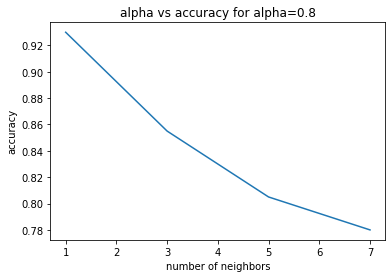

In [ ]:
import matplotlib.pyplot as plt
plt.plot(k_values,accuracy_R0)

# Set axis labels and title
plt.xlabel('number of neighbors')
plt.ylabel('accuracy')
plt.title('alpha vs accuracy for alpha=0.8')

# Show the plot
plt.show()

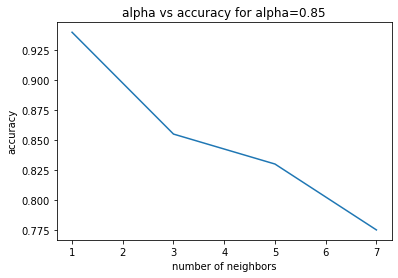

In [ ]:
import matplotlib.pyplot as plt
plt.plot(k_values,accuracy_R1)

# Set axis labels and title
plt.xlabel('number of neighbors')
plt.ylabel('accuracy')
plt.title('alpha vs accuracy for alpha=0.85')

# Show the plot
plt.show()

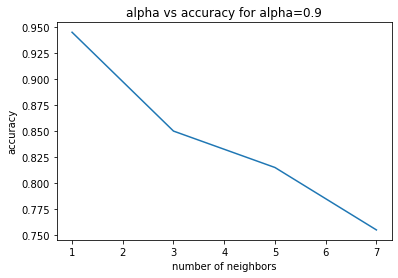

In [ ]:
import matplotlib.pyplot as plt
plt.plot(k_values,accuracy_R2)

# Set axis labels and title
plt.xlabel('number of neighbors')
plt.ylabel('accuracy')
plt.title('alpha vs accuracy for alpha=0.9')

# Show the plot
plt.show()

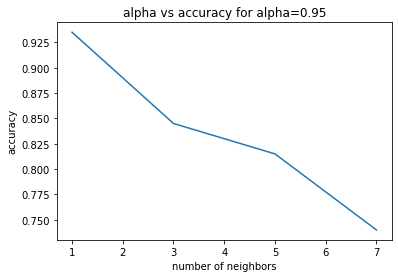

In [ ]:
import matplotlib.pyplot as plt
plt.plot(k_values,accuracy_R3)

# Set axis labels and title
plt.xlabel('number of neighbors')
plt.ylabel('accuracy')
plt.title('alpha vs accuracy for alpha=0.95')

# Show the plot
plt.show()

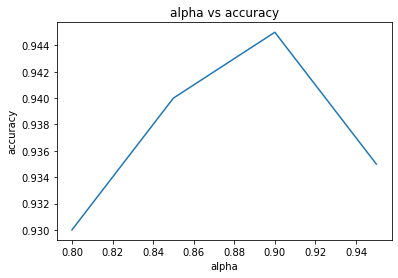

In [ ]:
import matplotlib.pyplot as plt
plt.plot([0.8,0.85,0.9,0.95], [accuracy_R0[0],accuracy_R1[0],accuracy_R2[0],accuracy_R3[0]])

# Set axis labels and title
plt.xlabel('alpha')
plt.ylabel('accuracy')
plt.title('alpha vs accuracy')

# Show the plot
plt.show()

5. LDA Classification

In [ ]:
#5
#compute mean face for each of 40 individuals in the dataset
Mu = np.zeros((40, 10304))
for i in range (0,40):
  Mu[i]=np.mean(Dtrain[(i*5):(i*5)+4,:], axis=0)
print(Mu[1].reshape(10304,1).shape)

(10304, 1)


In [ ]:
#compute the between class scatter matrix for 40 individuals
Sb=np.zeros((10304,10304))
for i in range (0,40):
  Sb=Sb+5*np.dot((Mu[i].reshape(10304,1)-np.mean(Dtrain, axis=0).reshape(10304,1)),(Mu[i].reshape(10304,1)-np.mean(Dtrain, axis=0).reshape(10304,1)).T)
print(Sb.shape)

(10304, 10304)


In [ ]:
#Compute centered image data for each individual
LDAcentertrain = np.zeros(((40,5,10304)))
for i in range(0,40):
  for j in range(0,5):
    LDAcentertrain[i,j]+=Dtrain[int(i*5+j)]-Mu[int(i)]

In [ ]:
#compute scatter matrix using LDA
S = np.zeros(((10304,10304)))
for i in range(0, 40):
    S+= np.matmul(LDAcentertrain[i].T,LDAcentertrain[i])

In [ ]:
#compute the inverse square matrix S
IS = np.linalg.inv(S)
#compute eigenvalues and eigenvectors
eigenvalues2, eigenvectors2 = np.linalg.eigh(np.dot(IS,Sb))
#sort the eigenvalues and eigenvectors descendingly
idx = np.argsort(-np.absolute(eigenvalues2))   
eigenValues2 = eigenvalues2[idx]
eigenVectors2 = eigenvectors2[:,idx]


In [ ]:
#perform dimensionality reduction on the training and test data 
#by projecting them onto a subspace spanned by the top 39 eigenvectors 
U5=eigenVectors2[:,:39]
projection_matrix = U5
projected_data9 = np.dot(projection_matrix.T, DTraincentered.T)
projected_data10 = np.dot(projection_matrix.T, DTestcentered.T)
#return the real part as new arrays
projected_data9_real = np.real(projected_data9.T)
projected_data10_real = np.real(projected_data10.T)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
#train a k-nearest neighbors classifier and then evaluates the accuracy
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(projected_data9_real, Ytrain)
print("Accuracy with R = 39: ", knn.score(projected_data10_real, Ytest))

Accuracy with R = 39:  0.935


/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


6. Classifier Tunning

In [ ]:
#6.classifier tuning for LDA
k_values = [1, 3, 5, 7]
accuracy=np.zeros(4)

for i in range (0,4):
  knn = KNeighborsClassifier(n_neighbors=k_values[i])
  knn.fit(projected_data9_real, Ytrain)
  accuracy[i]=knn.score(projected_data10_real, Ytest)
  print("Accuracy with number of neighbors ",k_values[i],": ", accuracy[i])

Accuracy with number of neighbors  1 :  0.935
Accuracy with number of neighbors  3 :  0.86
Accuracy with number of neighbors  5 :  0.795
Accuracy with number of neighbors  7 :  0.775


/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exam

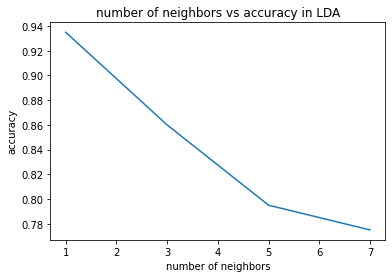

In [ ]:
import matplotlib.pyplot as plt
plt.plot(k_values, accuracy)

# Set axis labels and title
plt.xlabel('number of neighbors')
plt.ylabel('accuracy')
plt.title('number of neighbors vs accuracy in LDA')

# Show the plot
plt.show()

7. Face Images VS Non-Face Images

In [ ]:
parent_folder = '/content/drive/MyDrive/PR/natural_images'

nonfacenum=700
width = 92
height = 112
D2 = np.zeros((int(400+nonfacenum), 10304))
DTraincentered2 = np.zeros((int(nonfacenum), 10304))
DTestcentered2 = np.zeros((400, 10304))
testc2=0
trainc2=0
Dtrain2 = np.zeros((int(nonfacenum), 10304))
Dtest2 = np.zeros((400, 10304))
Y2 = np.zeros((int(400+nonfacenum),1))
Ytrain2 = np.zeros((int(nonfacenum), 1))
Ytest2 = np.zeros((400, 1))
D2[0:400]=D
Y2=[np.ones((1,400)),np.zeros((1,int(nonfacenum)))]
s=400
# for sub in range(1,41):
for filename in os.listdir(parent_folder):
  folder_path = f"{parent_folder}/{filename}"
  for i in range(0,100):
    if i<10:
      filename2 = f"{folder_path}/{filename}_000{i}.jpg" 
    else:
      filename2 = f"{folder_path}/{filename}_00{i}.jpg" 
    image = Image.open(filename2)
    image = image.resize((92, 112))
    image = image.convert('L')  
    image_array = np.array(image)
    D2[s] = image_array.flatten()
    s=s+1
    
np.random.shuffle(D2[0:400])
np.random.shuffle(D2[400:int(nonfacenum+400)])
Dtrain2[0:200]=D2[0:200]
Dtrain2[200:int(nonfacenum)]=D2[400:int(nonfacenum)+200]
Ytrain2[0:200]=np.ones((200,1))
Dtest2[0:200]=D2[200:400]
Dtest2[200:400]=D2[int(nonfacenum+200):int(nonfacenum+400)]
Ytest2[0:200]=np.ones((200,1))



In [ ]:
for i in range(0,10304):
  DTraincentered2[:,i]=Dtrain2[:,i]-Dtrain2[:,i].mean()

for i in range(0,10304):
  DTestcentered2[:,i]=Dtest2[:,i]-Dtrain2[:,i].mean()

In [ ]:
covarianceMatrix22 = np.cov(DTraincentered2.T)
eigenvalues22, eigenvectors22 = np.linalg.eigh(covarianceMatrix22)

In [ ]:
idx = np.argsort(-(eigenvalues22))   
eigenValues22 = eigenvalues22[idx]
eigenVectors22 = eigenvectors22[:,idx]

In [ ]:
print (eigenValues22[0])
print (eigenValues22[10303])
print(eigenVectors22.shape)
print(np.abs(eigenValues22).min())

13359435.705318594
-6.267436141688631e-09
(10304, 10304)
2.3404536435172384e-16


In [ ]:
for i in range(0,int(nonfacenum)):
  explained=eigenValues22[0:i].sum()/eigenValues22.sum()
  if explained > 0.9:
    R=i
    break
print(R)

124


In [ ]:
U21=eigenVectors22[:,:int(R)]
projection_matrix = U21
projected_data21 = np.dot(projection_matrix.T, DTraincentered2.T)
projected_data22 = np.dot(projection_matrix.T, DTestcentered2.T)

In [ ]:
projected_data21 = np.real(projected_data21.T)
projected_data22 = np.real(projected_data22.T)

In [ ]:
print(projection_matrix.shape)
print(DTraincentered2.shape)
print(projected_data21.T.shape)
print(Ytrain2.shape)
print(projected_data22.T.shape)
print(Ytest2.shape)

(10304, 124)
(700, 10304)
(124, 700)
(700, 1)
(124, 400)
(400, 1)


In [ ]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(projected_data21, Ytrain2)
print("Accuracy with R = ", R, ": ", knn.score(projected_data22, Ytest2))

Accuracy with R =  124 :  0.935


/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [ ]:
Mu1=np.mean(Dtrain2[:200,:], axis=0)
Mu2=np.mean(Dtrain2[200:,:], axis=0)

In [ ]:
print(Dtrain2[:200,:].shape)
print(Dtrain2[200:,:].shape)

(200, 10304)
(500, 10304)


In [ ]:
# Sb=np.dot(((Mu1-Mu2).reshape(10304,1)),(Mu1-Mu2).reshape(10304,1).T)


Sb=np.zeros((10304,10304))
Sb=200*np.dot((Mu1.reshape(10304,1)-np.mean(Dtrain, axis=0).reshape(10304,1)),(Mu1.reshape(10304,1)-np.mean(Dtrain, axis=0).reshape(10304,1)).T)+500*np.dot((Mu2.reshape(10304,1)-np.mean(Dtrain, axis=0).reshape(10304,1)),(Mu2.reshape(10304,1)-np.mean(Dtrain, axis=0).reshape(10304,1)).T)
#print(Sb)

[[2150774.738  2165517.314  2121246.077  ... 2296722.628  2424121.105
  2496898.476 ]
 [2165517.314  2180363.887  2135791.646  ... 2312425.309  2440723.29
  2513971.423 ]
 [2121246.077  2135791.646  2092132.7255 ... 2265116.287  2390813.8075
  2462540.469 ]
 ...
 [2296722.628  2312425.309  2265116.287  ... 2453126.093  2588810.255
  2666910.831 ]
 [2424121.105  2440723.29   2390813.8075 ... 2588810.255  2732274.7375
  2814435.685 ]
 [2496898.476  2513971.423  2462540.469  ... 2666910.831  2814435.685
  2899327.397 ]]


In [ ]:
LDAcentertrain22=np.zeros((nonfacenum,10304))
i=0
for r in Dtrain2:
  if i<200:
    LDAcentertrain22[i]=r-Mu1
  else:
    LDAcentertrain22[i]=r-Mu2
  i=i+1


In [ ]:
S1=np.matmul(LDAcentertrain22[:200,:].T,LDAcentertrain22[:200,:])
S2=np.matmul(LDAcentertrain22[200:,:].T,LDAcentertrain22[200:,:])
S=S1+S2
# S=np.cov(S)

In [ ]:
IS = np.linalg.inv(S)

In [ ]:
eigenvalues22, eigenvectors22 = np.linalg.eigh(np.dot(IS,Sb))

In [ ]:
idx = np.argsort(-(eigenvalues22))   
eigenValues22 = eigenvalues22[idx]
eigenVectors22 = eigenvectors22[:,idx]

In [ ]:
U22=eigenVectors22[:,:2]
projection_matrix = U22
projected_data22 = np.dot(projection_matrix.T, DTraincentered2.T)
projected_data222 = np.dot(projection_matrix.T, DTestcentered2.T)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(projected_data22.T, Ytrain2)
print("Accuracy with R = 1: ", knn.score(projected_data222.T, Ytest2))

Accuracy with R = 1:  0.84


/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


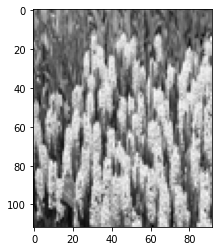

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

plt.imshow(Dtrain2[200].reshape(112,92), cmap='gray')

# Show the plot
plt.show()

In [ ]:
print(projected_data22.T.shape)
print(Ytrain2.shape)
print(projected_data222.T.shape)
print(Ytest2.shape)
print(projected_data22[0,300])

(700, 2)
(700, 1)
(400, 2)
(400, 1)
-365.5653111581256


8. Bonus

In [17]:
from PIL import Image
import numpy as np
import os

Bonus Part One

In [18]:
#Bonus Part1 
from PIL import Image
import numpy as np
import os

parent_folder = '/content/drive/MyDrive/PR/assignment1'
width = 92
height = 112
D = np.zeros((400, 10304))
DTraincentered73 = np.zeros((280, 10304))
DTestcentered73 = np.zeros((120, 10304))
testc = 0
trainc = 0
Dtrain73 = np.zeros((280, 10304))
Dtest73 = np.zeros((120, 10304))
Y = np.zeros(400)
Ytrain73 = np.zeros((280, 1))
Ytest73 = np.zeros((120, 1))

for sub in range(1, 41):
    folder_path = f"{parent_folder}/s{sub}"
    sub_data = np.zeros((10, 10304))
    for i in range(1, 11):
        filename = f"{folder_path}/{i}.pgm"
        image = Image.open(filename)
        image_array = np.array(image)
        sub_data[(i - 1), :] = image_array.flatten()
    
    np.random.shuffle(sub_data)
    train_data = sub_data[:7, :]
    test_data = sub_data[7:, :]
    #7 instances for train w 3 for test 
    Dtrain73[trainc:trainc+7, :] = train_data
    Dtest73[testc:testc+3, :] = test_data
    Ytrain73[trainc:trainc+7, 0] = sub
    Ytest73[testc:testc+3, 0] = sub
    trainc += 7
    testc += 3


DTraincentered73 = Dtrain73 - np.mean(Dtrain73, axis=0)
DTestcentered73 = Dtest73 - np.mean(Dtrain73, axis=0)

In [19]:
#using part 1 in the default PCA algorithm
covarianceMatrix73 = np.cov(DTraincentered73.T)
                          
eigenvalues73, eigenvectors73 = np.linalg.eigh(covarianceMatrix73)

idx = np.argsort(-np.absolute(eigenvalues73))   
eigenValues73 = eigenvalues73[idx]
eigenVectors73 = eigenvectors73[:,idx]

print (eigenValues73[0])
print (eigenValues73[10303])
print(eigenVectors73.shape)
print(np.abs(eigenValues73).min())

2782324.3389784987
1.2488406077069273e-16
(10304, 10304)
1.2488406077069273e-16


In [20]:
R=np.zeros(4)
for i in range(0,200):
  explained=eigenValues73[0:i].sum()/eigenValues73.sum()
  if explained > 0.8:
    R[0]=i
    break
for i in range(i,200):
  explained=eigenValues73[0:i].sum()/eigenValues73.sum()
  if explained > 0.85:
    R[1]=i
    break
for i in range(i,200):
  explained=eigenValues73[0:i].sum()/eigenValues73.sum()
  if explained > 0.9:
    R[2]=i
    break
for i in range(i,200):
  explained=eigenValues73[0:i].sum()/eigenValues73.sum()
  if explained > 0.95:
    R[3]=i
    break
print(R)

[ 40.  59.  91. 148.]


In [21]:
U1_73=eigenVectors73[:,:int(R[0])]
U2_73=eigenVectors73[:,:int(R[1])]
U3_73=eigenVectors73[:,:int(R[2])]
U4_73=eigenVectors73[:,:int(R[3])]

projection_matrix73 = U1_73
projected_data173 = np.dot(projection_matrix73.T, DTraincentered73.T)
projection_matrix73 = U2_73
projected_data273 = np.dot(projection_matrix73.T, DTraincentered73.T)
projection_matrix73 = U3_73
projected_data373 = np.dot(projection_matrix73.T, DTraincentered73.T)
projection_matrix73 = U4_73
projected_data473 = np.dot(projection_matrix73.T, DTraincentered73.T)


projection_matrix73 = U1_73
projected_data573 = np.dot(projection_matrix73.T, DTestcentered73.T)
projection_matrix73 = U2_73
projected_data673 = np.dot(projection_matrix73.T, DTestcentered73.T)
projection_matrix73 = U3_73
projected_data773 = np.dot(projection_matrix73.T, DTestcentered73.T)
projection_matrix73 = U4_73
projected_data873 = np.dot(projection_matrix73.T, DTestcentered73.T)

projected_data1_real73 = np.real(projected_data173.T)
projected_data2_real73 = np.real(projected_data273.T)
projected_data3_real73 = np.real(projected_data373.T)
projected_data4_real73 = np.real(projected_data473.T)
projected_data5_real73 = np.real(projected_data573.T)
projected_data6_real73 = np.real(projected_data673.T)
projected_data7_real73 = np.real(projected_data773.T)
projected_data8_real73 = np.real(projected_data873.T)

In [22]:
from sklearn.neighbors import KNeighborsClassifier
knn73 = KNeighborsClassifier(n_neighbors=1)
knn73.fit(projected_data1_real73, Ytrain73)
print("Accuracy with R = ", R[0], ": ", knn73.score(projected_data5_real73, Ytest73))

knn73 = KNeighborsClassifier(n_neighbors=1)
knn73.fit(projected_data2_real73, Ytrain73)
print("Accuracy with R = ", R[1], ": ", knn73.score(projected_data6_real73, Ytest73))

knn73 = KNeighborsClassifier(n_neighbors=1)
knn73.fit(projected_data3_real73, Ytrain73)
print("Accuracy with R = ", R[2], ": ", knn73.score(projected_data7_real73, Ytest73))

knn73 = KNeighborsClassifier(n_neighbors=1)
knn73.fit(projected_data4_real73, Ytrain73)
print("Accuracy with R = ", R[3], ": ", knn73.score(projected_data8_real73, Ytest73))

Accuracy with R =  40.0 :  0.975
Accuracy with R =  59.0 :  0.9666666666666667
Accuracy with R =  91.0 :  0.9666666666666667
Accuracy with R =  148.0 :  0.975


/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exam

In [23]:
k_values = [1, 3, 5, 7]

accuracy_R073=np.zeros(4)
accuracy_R173=np.zeros(4)
accuracy_R273=np.zeros(4)
accuracy_R373=np.zeros(4)

for i in range(0,4):
  knn73 = KNeighborsClassifier(n_neighbors=k_values[i])
  k73=np.zeros(4)
  knn73.fit(projected_data1_real73, Ytrain73)
  accuracy_R073[i]=knn73.score(projected_data5_real73, Ytest73)
  print("Accuracy with R = ", R[0], "and number of neighbors =",k_values[i],": ", accuracy_R073[i])

  knn73 = KNeighborsClassifier(n_neighbors=k_values[i])
  knn73.fit(projected_data2_real73, Ytrain73)
  accuracy_R173[i]=knn73.score(projected_data6_real73, Ytest73)
  print("Accuracy with R = ", R[1],"and number of neighbors =",k_values[i], ": ",  accuracy_R173[i] )

  knn73 = KNeighborsClassifier(n_neighbors=k_values[i])
  knn73.fit(projected_data3_real73, Ytrain73)
  accuracy_R273[i]=knn73.score(projected_data7_real73, Ytest73)
  print("Accuracy with R = ", R[2],"and number of neighbors =",k_values[i], ": ", accuracy_R273[i])

  knn73 = KNeighborsClassifier(n_neighbors=k_values[i])
  knn73.fit(projected_data4_real73, Ytrain73)
  accuracy_R373[i]=knn73.score(projected_data8_real73, Ytest73)
  print("Accuracy with R = ", R[3],"and number of neighbors =",k_values[i], ": ", accuracy_R373[i])

/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exam

Accuracy with R =  40.0 and number of neighbors = 1 :  0.975
Accuracy with R =  59.0 and number of neighbors = 1 :  0.9666666666666667
Accuracy with R =  91.0 and number of neighbors = 1 :  0.9666666666666667
Accuracy with R =  148.0 and number of neighbors = 1 :  0.975
Accuracy with R =  40.0 and number of neighbors = 3 :  0.9
Accuracy with R =  59.0 and number of neighbors = 3 :  0.925
Accuracy with R =  91.0 and number of neighbors = 3 :  0.9166666666666666
Accuracy with R =  148.0 and number of neighbors = 3 :  0.925
Accuracy with R =  40.0 and number of neighbors = 5 :  0.875
Accuracy with R =  59.0 and number of neighbors = 5 :  0.8833333333333333
Accuracy with R =  91.0 and number of neighbors = 5 :  0.9
Accuracy with R =  148.0 and number of neighbors = 5 :  0.9083333333333333
Accuracy with R =  40.0 and number of neighbors = 7 :  0.85
Accuracy with R =  59.0 and number of neighbors = 7 :  0.825
Accuracy with R =  91.0 and number of neighbors = 7 :  0.8416666666666667
Accuracy 

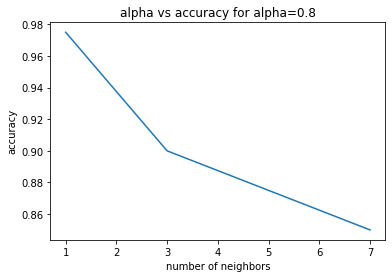

In [24]:
import matplotlib.pyplot as plt
plt.plot(k_values,accuracy_R073)

# Set axis labels and title
plt.xlabel('number of neighbors')
plt.ylabel('accuracy')
plt.title('alpha vs accuracy for alpha=0.8')

# Show the plot
plt.show()

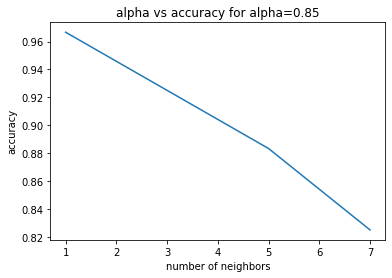

In [25]:
import matplotlib.pyplot as plt
plt.plot(k_values,accuracy_R173)

# Set axis labels and title
plt.xlabel('number of neighbors')
plt.ylabel('accuracy')
plt.title('alpha vs accuracy for alpha=0.85')

# Show the plot
plt.show()

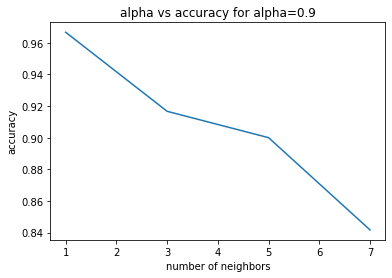

In [26]:
import matplotlib.pyplot as plt
plt.plot(k_values,accuracy_R273)

# Set axis labels and title
plt.xlabel('number of neighbors')
plt.ylabel('accuracy')
plt.title('alpha vs accuracy for alpha=0.9')

# Show the plot
plt.show()

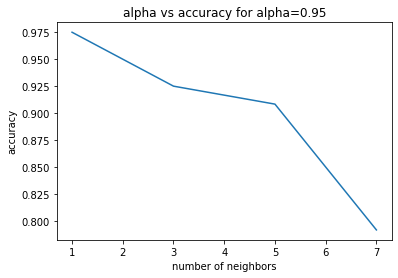

In [27]:
import matplotlib.pyplot as plt
plt.plot(k_values,accuracy_R373)

# Set axis labels and title
plt.xlabel('number of neighbors')
plt.ylabel('accuracy')
plt.title('alpha vs accuracy for alpha=0.95')

# Show the plot
plt.show()

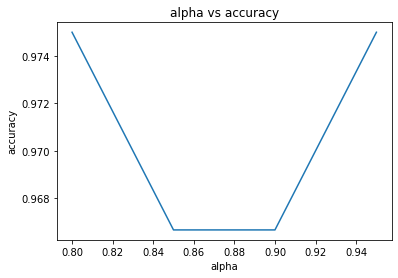

In [28]:
import matplotlib.pyplot as plt
plt.plot([0.8,0.85,0.9,0.95], [accuracy_R073[0],accuracy_R173[0],accuracy_R273[0],accuracy_R373[0]])

# Set axis labels and title
plt.xlabel('alpha')
plt.ylabel('accuracy')
plt.title('alpha vs accuracy')

# Show the plot
plt.show()

In [29]:
#LDA 70 30
#compute mean face for each of 40 individuals in the dataset
Mu73 = np.zeros((40, 10304))
for i in range (0,40):
  Mu73[i]=np.mean(Dtrain73[(i*5):(i*5)+4,:], axis=0)
print(Mu73[1].reshape(10304,1).shape)

(10304, 1)


In [33]:
#compute the between class scatter matrix for 40 individuals
Sb73=np.zeros((10304,10304))
for i in range (0,40):
  Sb73=Sb73+5*np.dot((Mu73[i].reshape(10304,1)-np.mean(Dtrain73, axis=0).reshape(10304,1)),(Mu73[i].reshape(10304,1)-np.mean(Dtrain73, axis=0).reshape(10304,1)).T)
print(Sb73.shape)

(10304, 10304)


In [31]:
#Compute centered image data for each individual
LDAcentertrain73 = np.zeros(((40,5,10304)))
for i in range(0,40):
  for j in range(0,5):
    LDAcentertrain73[i,j]+=Dtrain73[int(i*5+j)]-Mu73[int(i)]

In [32]:
#compute scatter matrix using LDA
S73 = np.zeros(((10304,10304)))
for i in range(0, 40):
    S73+= np.matmul(LDAcentertrain73[i].T,LDAcentertrain73[i])

In [ ]:
#compute the inverse square matrix S
IS73 = np.linalg.inv(S73)
#compute eigenvalues and eigenvectors
eigenvalues273, eigenvectors273 = np.linalg.eigh(np.dot(IS73,Sb73))
#sort the eigenvalues and eigenvectors descendingly
idx73 = np.argsort(-np.absolute(eigenvalues273))   
eigenValues273 = eigenvalues273[idx73]
eigenVectors273 = eigenvectors273[:,idx73]


In [ ]:
#perform dimensionality reduction on the training and test data 
#by projecting them onto a subspace spanned by the top 39 eigenvectors 
U573=eigenVectors273[:,:39]
projection_matrix73 = U573
projected_data973 = np.dot(projection_matrix73.T, DTraincentered73.T)
projected_data1073 = np.dot(projection_matrix73.T, DTestcentered73.T)
#return the real part as new arrays
projected_data9_real73 = np.real(projected_data973.T)
projected_data10_real73 = np.real(projected_data1073.T)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
#train a k-nearest neighbors classifier and then evaluates the accuracy
knn73 = KNeighborsClassifier(n_neighbors=1)
knn73.fit(projected_data9_real73, Ytrain73)
print("Accuracy with R = 39: ", knn.score(projected_data10_real73, Ytest73))

Bonus Part Two: Incremental PCA

In [ ]:
#Bonus Part2 Incremental PCA
from PIL import Image
import numpy as np
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import IncrementalPCA

parent_folder = '/content/drive/MyDrive/PR/assignment1'

width = 92
height = 112
D = np.zeros((400, 10304))
DTraincentered = np.zeros((200, 10304))
DTestcentered = np.zeros((200, 10304))
testc=0
trainc=0
Dtrain = np.zeros((200, 10304))
Dtest = np.zeros((200, 10304))
Y = np.zeros(400)
Ytrain = np.zeros((200, 1))
Ytest = np.zeros((200, 1))

for sub in range(1,41):
  folder_path = f"{parent_folder}/s{sub}"
  for i in range(1,11):
    filename = f"{folder_path}/{i}.pgm" 
    image = Image.open(filename) 
    image_array = np.array(image)
    D[(sub-1)*10+(i-1)] = image_array.flatten() 
    Y[(sub-1)*10+(i-1)] = sub
    if (i % 2) != 0:
      Dtest[testc] = D[(sub-1)*10+(i-1)]
      Ytest[int(testc)] = Y[(sub-1)*10+(i-1)]
      testc=testc+1
    else:
      Dtrain[trainc] = D[(sub-1)*10+(i-1)]
      Ytrain[int(trainc)] = Y[(sub-1)*10+(i-1)]
      trainc=trainc+1

for i in range(0,10304):
  DTraincentered[:,i]=Dtrain[:,i]-Dtrain[:,i].mean()

for i in range(0,10304):
  DTestcentered[:,i]=Dtest[:,i]-Dtrain[:,i].mean()

n_components = 200
batch_size = 50

ipca = IncrementalPCA(n_components=n_components, batch_size=batch_size)
ipca.fit(DTraincentered)
eigenValues = ipca.explained_variance_
eigenVectors = ipca.components_.T

idx = np.argsort(-np.absolute(eigenValues))   
eigenVal = eigenValues[idx]
eigenVec = eigenVectors[:,idx]


print(eigenVectors.shape)


(10304, 200)


In [ ]:
R=np.zeros(4)
for i in range(0,200):
  explained=eigenVal[0:i].sum()/eigenVal.sum()
  if explained > 0.8:
    R[0]=i
    break
for i in range(i,200):
  explained=eigenVal[0:i].sum()/eigenVal.sum()
  if explained > 0.85:
    R[1]=i
    break
for i in range(i,200):
  explained=eigenVal[0:i].sum()/eigenVal.sum()
  if explained > 0.9:
    R[2]=i
    break
for i in range(i,200):
  explained=eigenVal[0:i].sum()/eigenVal.sum()
  if explained > 0.95:
    R[3]=i
    break
print(R)

[ 37.  53.  77. 116.]


In [ ]:
U1=eigenVec[:,:int(R[0])]
U2=eigenVec[:,:int(R[1])]
U3=eigenVec[:,:int(R[2])]
U4=eigenVec[:,:int(R[3])]

In [ ]:
projection_matrix = U1
projected_data1 = np.dot(projection_matrix.T, DTraincentered.T)
projection_matrix = U2
projected_data2 = np.dot(projection_matrix.T, DTraincentered.T)
projection_matrix = U3
projected_data3 = np.dot(projection_matrix.T, DTraincentered.T)
projection_matrix = U4
projected_data4 = np.dot(projection_matrix.T, DTraincentered.T)

projection_matrix = U1
projected_data5 = np.dot(projection_matrix.T, DTestcentered.T)
projection_matrix = U2
projected_data6 = np.dot(projection_matrix.T, DTestcentered.T)
projection_matrix = U3
projected_data7 = np.dot(projection_matrix.T, DTestcentered.T)
projection_matrix = U4
projected_data8 = np.dot(projection_matrix.T, DTestcentered.T)

projected_data1_real = np.real(projected_data1.T)
projected_data2_real = np.real(projected_data2.T)
projected_data3_real = np.real(projected_data3.T)
projected_data4_real = np.real(projected_data4.T)
projected_data5_real = np.real(projected_data5.T)
projected_data6_real = np.real(projected_data6.T)
projected_data7_real = np.real(projected_data7.T)
projected_data8_real = np.real(projected_data8.T)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(projected_data1_real, Ytrain)
print("Accuracy with R = ", R[0], ": ", knn.score(projected_data5_real, Ytest))

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(projected_data2_real, Ytrain)
print("Accuracy with R = ", R[1], ": ", knn.score(projected_data6_real, Ytest))

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(projected_data3_real, Ytrain)
print("Accuracy with R = ", R[2], ": ", knn.score(projected_data7_real, Ytest))

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(projected_data4_real, Ytrain)
print("Accuracy with R = ", R[3], ": ", knn.score(projected_data8_real, Ytest))

/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy with R =  37.0 :  0.93
Accuracy with R =  53.0 :  0.94
Accuracy with R =  77.0 :  0.945
Accuracy with R =  116.0 :  0.935


/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [ ]:
k_values = [1, 3, 5, 7]

accuracy_R0=np.zeros(4)
accuracy_R1=np.zeros(4)
accuracy_R2=np.zeros(4)
accuracy_R3=np.zeros(4)

for i in range(0,4):
  knn = KNeighborsClassifier(n_neighbors=k_values[i])
  k=np.zeros(4)
  knn.fit(projected_data1_real, Ytrain)
  accuracy_R0[i]=knn.score(projected_data5_real, Ytest)
  print("Accuracy with R = ", R[0], "and number of neighbors =",k_values[i],": ", accuracy_R0[i])

  knn = KNeighborsClassifier(n_neighbors=k_values[i])
  knn.fit(projected_data2_real, Ytrain)
  accuracy_R1[i]=knn.score(projected_data6_real, Ytest)
  print("Accuracy with R = ", R[1],"and number of neighbors =",k_values[i], ": ",  accuracy_R1[i] )

  knn = KNeighborsClassifier(n_neighbors=k_values[i])
  knn.fit(projected_data3_real, Ytrain)
  accuracy_R2[i]=knn.score(projected_data7_real, Ytest)
  print("Accuracy with R = ", R[2],"and number of neighbors =",k_values[i], ": ", accuracy_R2[i])

  knn = KNeighborsClassifier(n_neighbors=k_values[i])
  knn.fit(projected_data4_real, Ytrain)
  accuracy_R3[i]=knn.score(projected_data8_real, Ytest)
  print("Accuracy with R = ", R[3],"and number of neighbors =",k_values[i], ": ", accuracy_R3[i])

/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exam

Accuracy with R =  37.0 and number of neighbors = 1 :  0.93
Accuracy with R =  53.0 and number of neighbors = 1 :  0.94
Accuracy with R =  77.0 and number of neighbors = 1 :  0.945
Accuracy with R =  116.0 and number of neighbors = 1 :  0.935
Accuracy with R =  37.0 and number of neighbors = 3 :  0.855


/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exam

Accuracy with R =  53.0 and number of neighbors = 3 :  0.855
Accuracy with R =  77.0 and number of neighbors = 3 :  0.85
Accuracy with R =  116.0 and number of neighbors = 3 :  0.845
Accuracy with R =  37.0 and number of neighbors = 5 :  0.805
Accuracy with R =  53.0 and number of neighbors = 5 :  0.83


/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exam

Accuracy with R =  77.0 and number of neighbors = 5 :  0.815
Accuracy with R =  116.0 and number of neighbors = 5 :  0.815
Accuracy with R =  37.0 and number of neighbors = 7 :  0.78
Accuracy with R =  53.0 and number of neighbors = 7 :  0.775
Accuracy with R =  77.0 and number of neighbors = 7 :  0.755
Accuracy with R =  116.0 and number of neighbors = 7 :  0.74


/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


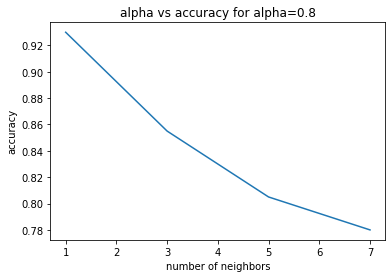

In [ ]:
import matplotlib.pyplot as plt
plt.plot(k_values,accuracy_R0)

# Set axis labels and title
plt.xlabel('number of neighbors')
plt.ylabel('accuracy')
plt.title('alpha vs accuracy for alpha=0.8')

# Show the plot
plt.show()

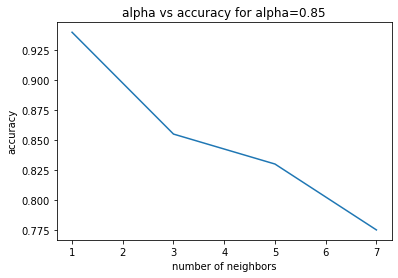

In [ ]:
import matplotlib.pyplot as plt
plt.plot(k_values,accuracy_R1)

# Set axis labels and title
plt.xlabel('number of neighbors')
plt.ylabel('accuracy')
plt.title('alpha vs accuracy for alpha=0.85')

# Show the plot
plt.show()

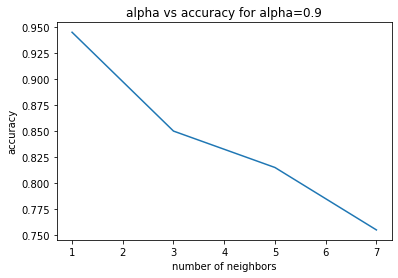

In [ ]:
import matplotlib.pyplot as plt
plt.plot(k_values,accuracy_R2)

# Set axis labels and title
plt.xlabel('number of neighbors')
plt.ylabel('accuracy')
plt.title('alpha vs accuracy for alpha=0.9')

# Show the plot
plt.show()

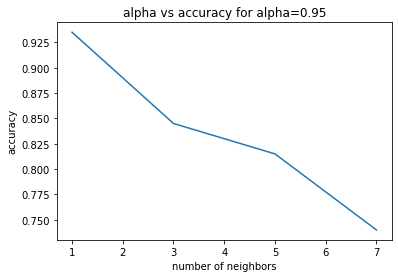

In [ ]:
import matplotlib.pyplot as plt
plt.plot(k_values,accuracy_R3)

# Set axis labels and title
plt.xlabel('number of neighbors')
plt.ylabel('accuracy')
plt.title('alpha vs accuracy for alpha=0.95')

# Show the plot
plt.show()

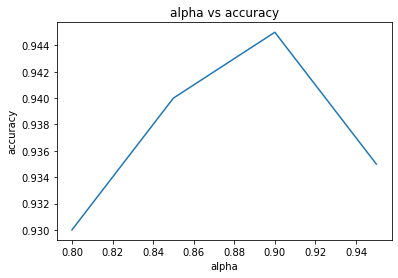

In [ ]:
import matplotlib.pyplot as plt
plt.plot([0.8,0.85,0.9,0.95], [accuracy_R0[0],accuracy_R1[0],accuracy_R2[0],accuracy_R3[0]])

# Set axis labels and title
plt.xlabel('alpha')
plt.ylabel('accuracy')
plt.title('alpha vs accuracy')

# Show the plot
plt.show()

Bonus Part Two LDA

In [ ]:
#Bonus Part2 LDA
from PIL import Image
import numpy as np
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import IncrementalPCA

parent_folder = '/content/drive/MyDrive/PR/assignment1'

width = 92
height = 112
D = np.zeros((400, 10304))
DTraincentered = np.zeros((200, 10304))
DTestcentered = np.zeros((200, 10304))
testc=0
trainc=0
Dtrain = np.zeros((200, 10304))
Dtest = np.zeros((200, 10304))
Y = np.zeros(400)
Ytrain = np.zeros((200, 1))
Ytest = np.zeros((200, 1))

for sub in range(1,41):
  folder_path = f"{parent_folder}/s{sub}"
  for i in range(1,11):
    filename = f"{folder_path}/{i}.pgm" 
    image = Image.open(filename) 
    image_array = np.array(image)
    D[(sub-1)*10+(i-1)] = image_array.flatten() 
    Y[(sub-1)*10+(i-1)] = sub
    if (i % 2) != 0:
      Dtest[testc] = D[(sub-1)*10+(i-1)]
      Ytest[int(testc)] = Y[(sub-1)*10+(i-1)]
      testc=testc+1
    else:
      Dtrain[trainc] = D[(sub-1)*10+(i-1)]
      Ytrain[int(trainc)] = Y[(sub-1)*10+(i-1)]
      trainc=trainc+1

for i in range(0,10304):
  DTraincentered[:,i]=Dtrain[:,i]-Dtrain[:,i].mean()

for i in range(0,10304):
  DTestcentered[:,i]=Dtest[:,i]-Dtrain[:,i].mean()

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
# Create the model with regularization
lda = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')

# Fit the model to the training data
lda.fit(Dtrain, Ytrain)

# Predict the class labels for the testing data
y_pred = lda.predict(Dtest)

# Evaluate the performance of the model
accuracy = accuracy_score(Ytest, y_pred)
print("Accuracy: {:.2f}%".format(accuracy * 100))

/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 98.50%
